## Understanding Message Passing

### Predicting if we find this meme funny or not

![funny-meme?](./gnn_data/meme.png)

If we want to aggregate information from everyone in this class we could ofcourse use a simple survey. In that case, we could just ask everyone if they find this meme funny or not. Then we could just take the average of all the answers and that would be our prediction. However, we lose an important piece of context when we do this analysis. Generally speaking, our feelings about a particular piece of content _does_ get influenced by the broader social context in which we find ourselves. We might find a meme funnier if we see that our friends also find it funny.

How do we capture that complexity? In this exercise we will find out, roughly in the same way social media algorithms leverage information from our social networks to predict what content we will find engaging.

We will create a graph network for this class. Each one of you is a node and you are connected to a few of your neighbors. Depending on where you sit in the room today, your "degree" (number of connections) will be different. But every one of you will be connected atleast one another and you will pass messages with each other. (Some people might have to move around a bit more to pass messages, but that's ok!)


First, we will assign a node ID for every one of you in a serial order. Remember that and take note of it here: 

In [1]:
import numpy as np
your_node = 0 


Great, and now for the "message". For this meme we will there might be three relevant piece of information that we want from you. Assuming you find this meme on Instagram, we might want to know:
- How likely are you to press like on this meme? (0-100% scale)
- How likely are you to share this meme with your friends? (0-100% scale)
- How likely are you to comment on this meme? (0-100% scale)

This can be your "feature vector" for this meme. You can write down your answers to these three questions here: 

In [2]:
press_like_probs = 80 
share_probs = 20
comment_probs = 10

# Indicate which cycle of message passing we are in. 
message_pass_cycle = 0 
your_feature_vector = {}
your_feature_vector[your_node] = {
    message_pass_cycle: [press_like_probs, share_probs, comment_probs]
}

print("Your feature vector:", your_feature_vector)

Your feature vector: {0: {0: [80, 20, 10]}}


Your neighbors are people who are sitting next to you, in front of you and behind you. We will make a live-demo of the graph to show the connections for everyone in the group so you know who your neighbors are. Watch the screen. 

Collect the feature vectors from your neighbors and write them down here:

In [3]:
# Uncomment and modify the following lines to define your neighbors and their features
neighbors_features = {}

# note down your neighbor's node id and their feature vectors
# Example:
neighbors_features[13] = {
    message_pass_cycle: [70, 30, 20]
}
neighbors_features[16] = {
    message_pass_cycle: [60, 25, 15]
}

print("Neighbors' feature vectors:")
for neighbor_id, features in neighbors_features.items():
    print(f"Neighbor {neighbor_id}: {features}")

Neighbors' feature vectors:
Neighbor 13: {0: [70, 30, 20]}
Neighbor 16: {0: [60, 25, 15]}


Aggregation step:
- You will then take the average of the feature vectors you received from your neighbors and update your own feature vector with this new information. This is the "message passing" step. But take note of how exactly are you going to aggregate the information? What are the conditions of the aggregating function? 
- This step of aggregating information from neighbors has to be done in a way that is invariant to the order of the neighbors, and it should be able to handle a variable number of neighbors. Let us consider a few ways to do it: 
1. **Concatenation**: You could concatenate the feature vectors of your neighbors. However, this approach is not invariant to the order of the neighbors and it does not handle a variable number of neighbors well. 
2. **Summation**: You could sum the feature vectors of your neighbors. This approach is invariant to the order of the neighbors and it can handle a variable number of neighbors. However, if you have a large number of neighbors, the summed feature vector might become very large. 
3. **Mean**: You could take the mean of the feature vectors of your neighbors. This approach is invariant to the order of the neighbors and it can handle a variable number of neighbors. It also keeps the feature vector at a manageable size regardless of the number of neighbors.
4. **Max**: You could take the max of the feature vectors of your neighbors. This approach is invariant to the order of the neighbors and it can handle a variable number of neighbors. However, it might lose some information about the distribution of the feature vectors among your neighbors.

**Summation**, **Mean** and **Max** are all valid aggregation functions for message passing in a graph neural network. They are "permutation invariant" because they do not depend on the order of the neighbors. However, the choice of this aggregating function can still have an impact on the performance of the model because by aggregating you are essentially compressing information. That will lead to loss of information, but the question is what information does really matter? That is something you decide on a case-by-case basis.

For now, let us choose the **Mean** as our aggregation function for this exercise.


In [4]:
# Aggregate the neighbors' feature vectors along with your own feature vector
concatenated_feature_vector = []
concatenated_feature_vector.append(your_feature_vector[your_node][message_pass_cycle])
for neighbor_id, features in neighbors_features.items():
    concatenated_feature_vector.append(features[message_pass_cycle])

concatenated_feature_vector = np.array(concatenated_feature_vector)
print("Concatenated feature vector:", concatenated_feature_vector)

# Now take the mean values for each column to get the aggregated feature vector
aggregated_feature_vector = np.mean(concatenated_feature_vector, axis=0).round(2)
print("Aggregated feature vector:", aggregated_feature_vector)

Concatenated feature vector: [[80 20 10]
 [70 30 20]
 [60 25 15]]
Aggregated feature vector: [70. 25. 15.]


That is the basic idea of message passing! Do this for one more round. 

In [5]:
message_pass_cycle = 1
# Update your feature vector with the aggregated feature vector for the next cycle
your_feature_vector[your_node][message_pass_cycle] = aggregated_feature_vector

print("Your feature vector looks like: ")
for node_id, features in your_feature_vector.items():
    print(f"Node {node_id}")
    for cycle, feature_vector in features.items():
        print(f"  Cycle {cycle}: {feature_vector}")

Your feature vector looks like: 
Node 0
  Cycle 0: [80, 20, 10]
  Cycle 1: [70. 25. 15.]


In [6]:
# Message passing with neighbors
neighbor_node_id = 13 # change this to match your neighbors
# Recieve message from your neighbor
neighbors_features[neighbor_node_id][message_pass_cycle] = [60, 30, 4]

# Do it for another neighbor
neighbor_node_id = 16 # change this to match your neighbors
# Recieve message from your neighbor
neighbors_features[neighbor_node_id][message_pass_cycle] = [50, 20, 10]
print("Updated neighbors' feature vectors after receiving messages:")
for neighbor_id, features in neighbors_features.items():
    print(f"Neighbor {neighbor_id}")
    for cycle, feature_vector in features.items():
        print(f"  Cycle {cycle}: {feature_vector}")

Updated neighbors' feature vectors after receiving messages:
Neighbor 13
  Cycle 0: [70, 30, 20]
  Cycle 1: [60, 30, 4]
Neighbor 16
  Cycle 0: [60, 25, 15]
  Cycle 1: [50, 20, 10]


In [7]:
# Concatenate the updated neighbors' feature vectors along with your own feature vector
concatenated_feature_vector_2 = []
message_pass_cycle = 1
concatenated_feature_vector_2.append(your_feature_vector[your_node][message_pass_cycle])
for neighbor_id, features in neighbors_features.items():
    concatenated_feature_vector_2.append(features[message_pass_cycle])
concatenated_feature_vector_2 = np.array(concatenated_feature_vector_2)

print("Concatenated feature vector after receiving messages:", concatenated_feature_vector_2)
# Now take the mean values for each column to get the aggregated feature vector
aggregated_feature_vector_2 = np.mean(concatenated_feature_vector_2, axis=0).round(2)
print("Aggregated feature vector after receiving messages:", aggregated_feature_vector_2)



Concatenated feature vector after receiving messages: [[70. 25. 15.]
 [60. 30.  4.]
 [50. 20. 10.]]
Aggregated feature vector after receiving messages: [60.   25.    9.67]


In [8]:
# Update your feature vector with the new aggregated feature vector 
message_pass_cycle = 2
your_feature_vector[your_node][message_pass_cycle] = aggregated_feature_vector_2
print("Your feature vector looks like: ")
for node_id, features in your_feature_vector.items():
    print(f"Node {node_id}")
    for cycle, feature_vector in features.items():
        print(f"  Cycle {cycle}: {feature_vector}")



Your feature vector looks like: 
Node 0
  Cycle 0: [80, 20, 10]
  Cycle 1: [70. 25. 15.]
  Cycle 2: [60.   25.    9.67]


We will end it here. Now, you have incorporated contextual information not just from your immediate neighbors, but also from the neighbors of your neighbors. 

For our exercise, think about what would happen if we were to repeat this process for many rounds? What would be the implications of that?

Go to the Google Sheets document and update your feature vectors for all the three cycles. We will then combine all your feature vectors into a single pooled vector. We will then apply weights to this pooled vector to make a prediction about how this class feels about the meme! 

Google sheet link: ___

Note in this step you did now use any weight while aggregating the information from your neighbors. Therefore, nothing was "trained" in this process. However, in a Graph Network you combine all the feature vectors from your neighbors through a common weight matrix shared by all the nodes in this network. 

In the update rule you followed there was no non-linearity involved. In a Graph Neural Network, you would typically apply a non-linear activation function (like ReLU) after the aggregation step to introduce non-linearity into the model. This allows the network to learn more complex patterns in the data.

The following illustration shows how message parsing works in a Graph Neural Network, from [DL4Proteins-notebooks](https://github.com/Graylab/DL4Proteins-notebooks)


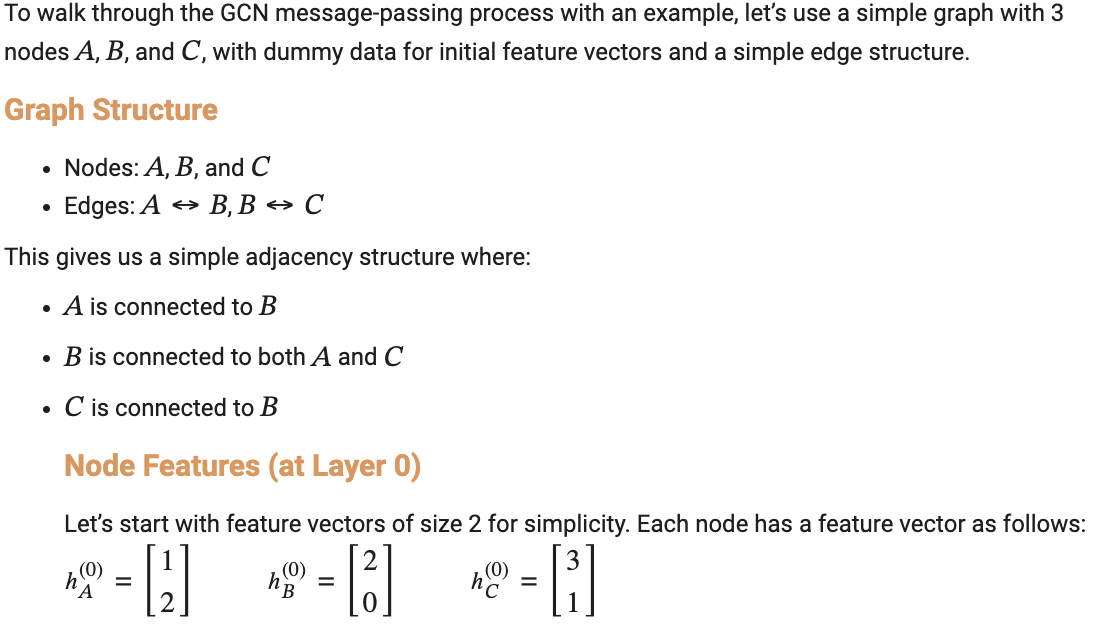
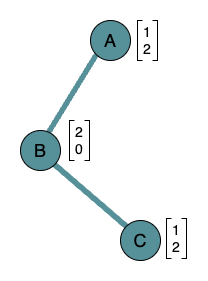
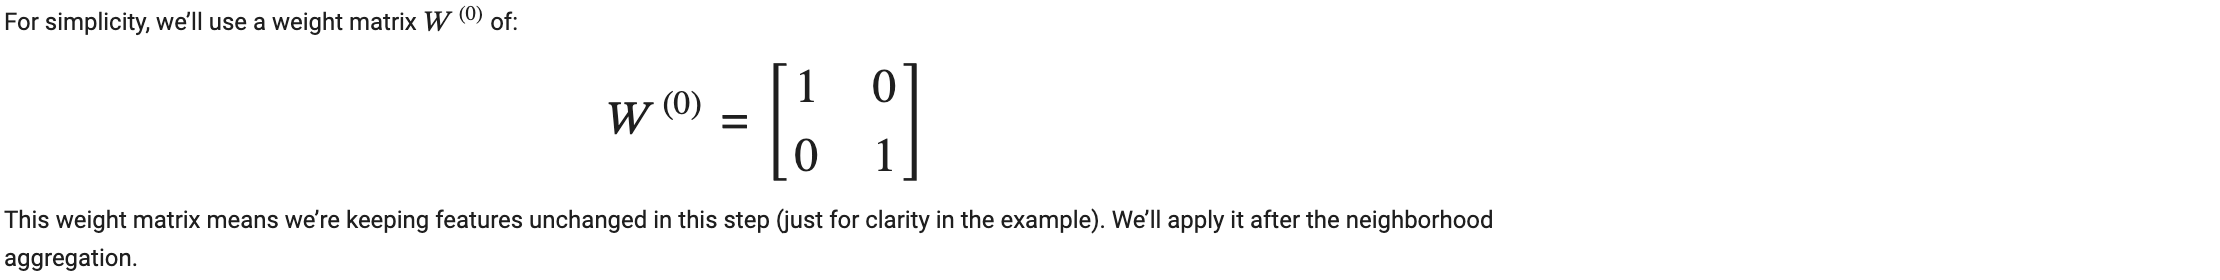
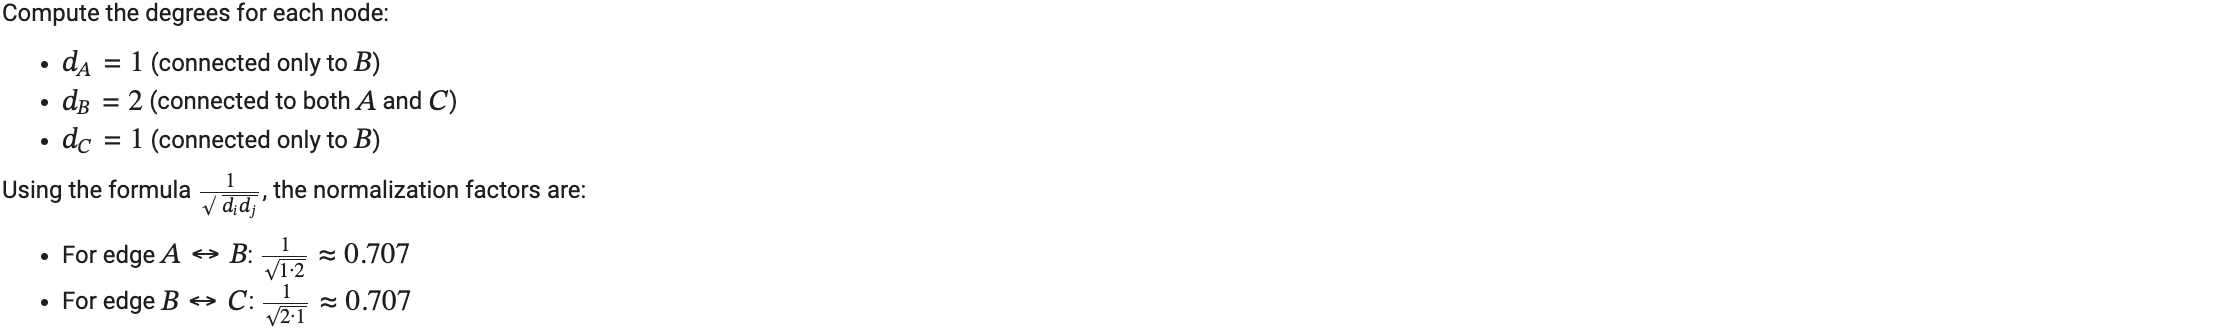
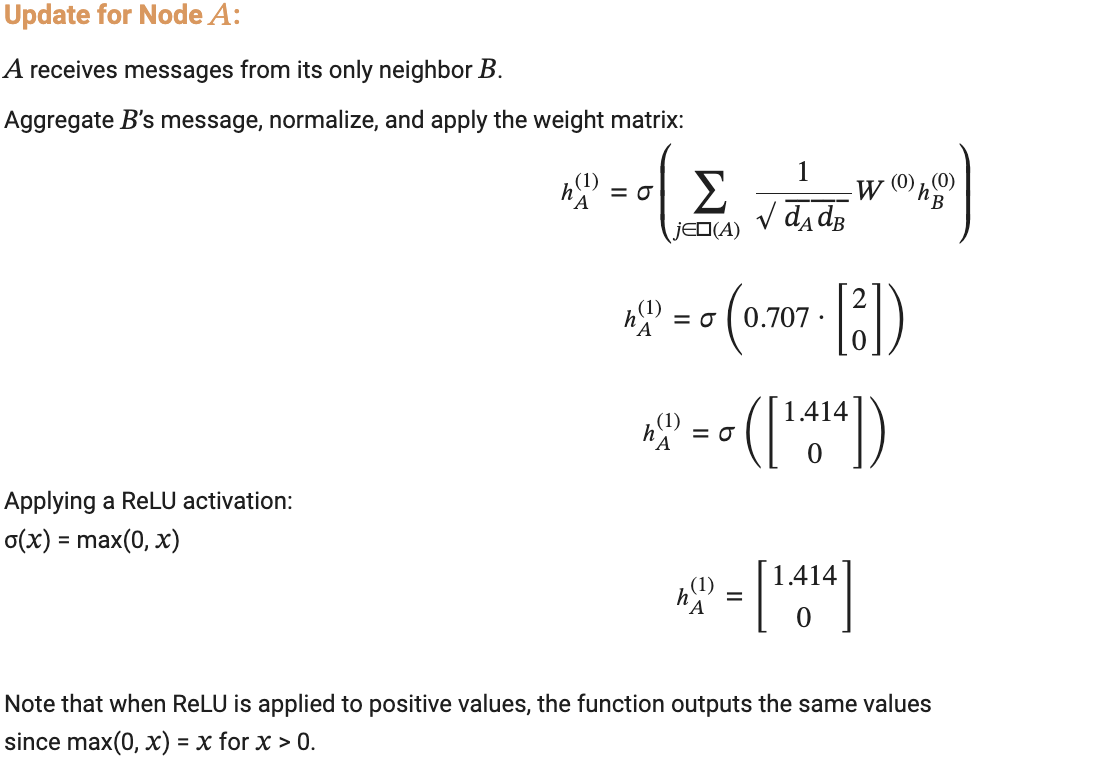
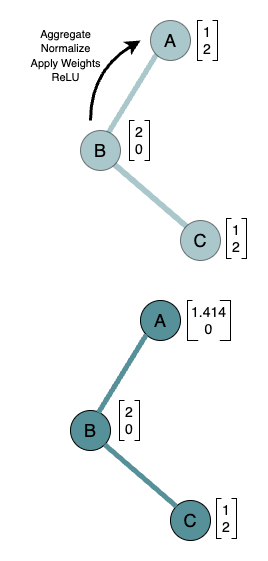
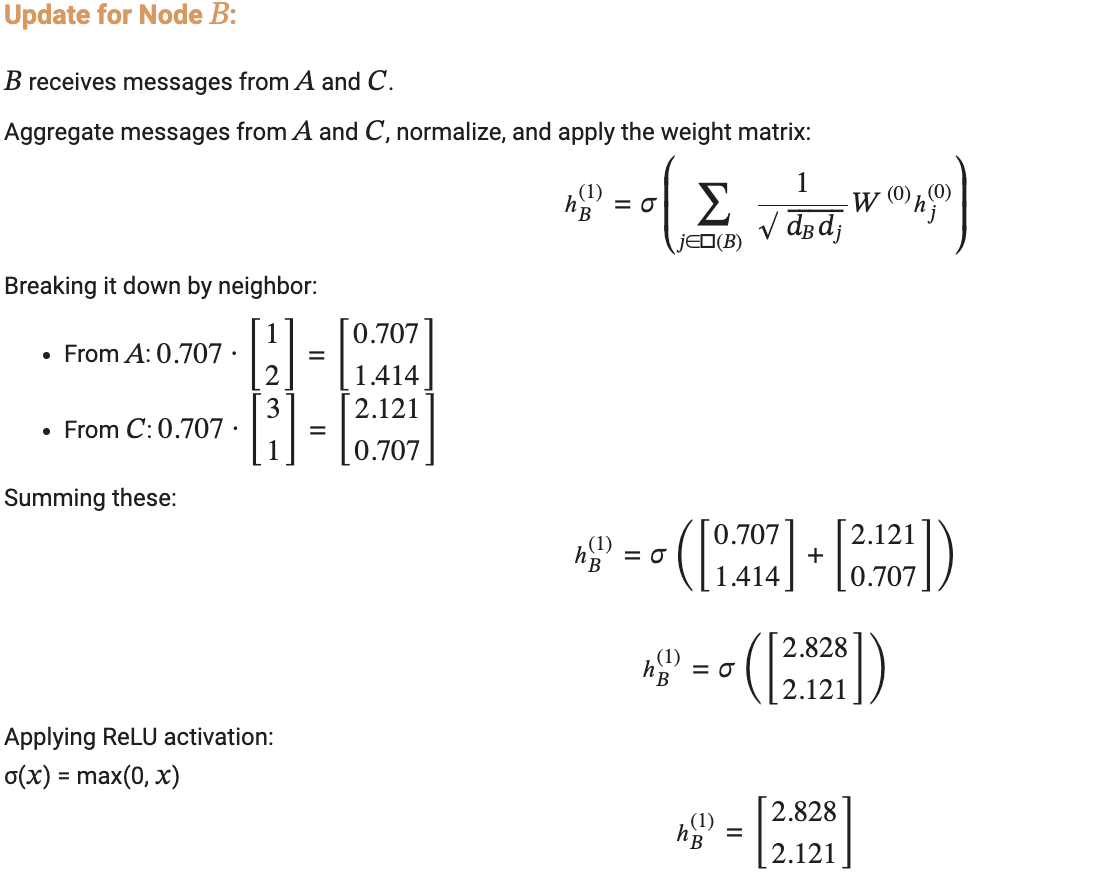
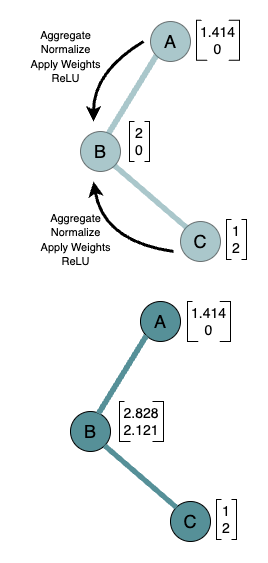
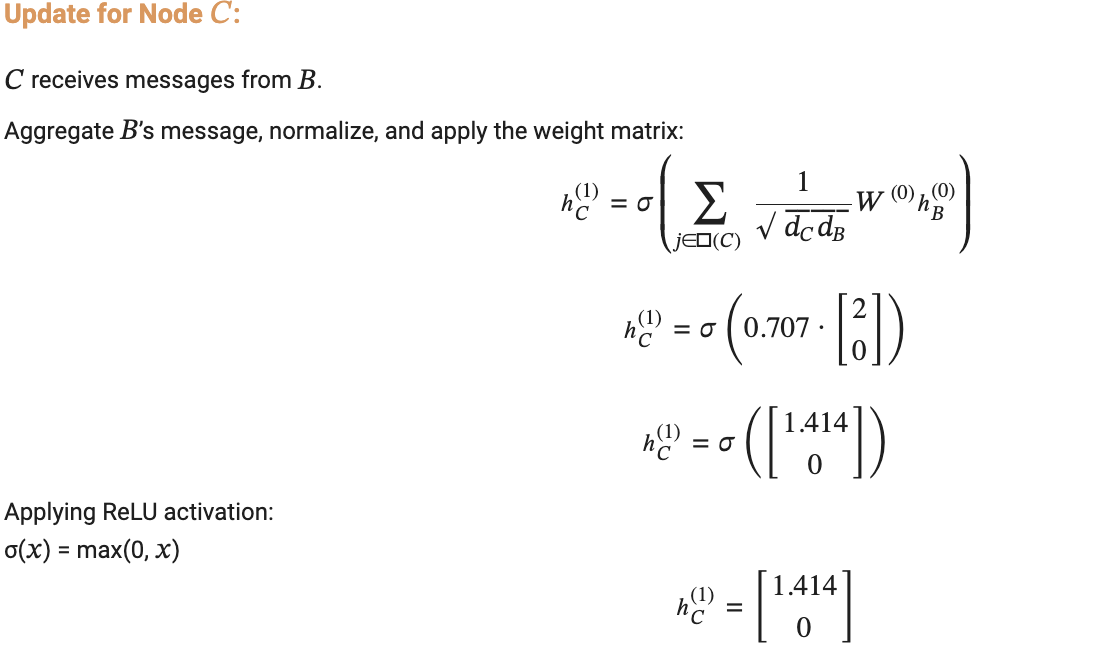
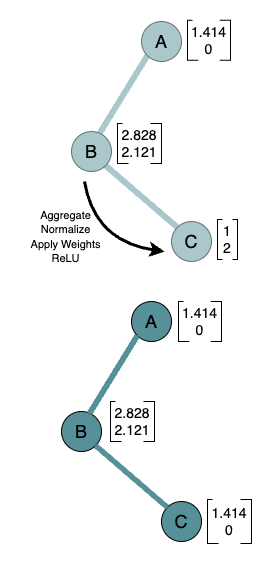
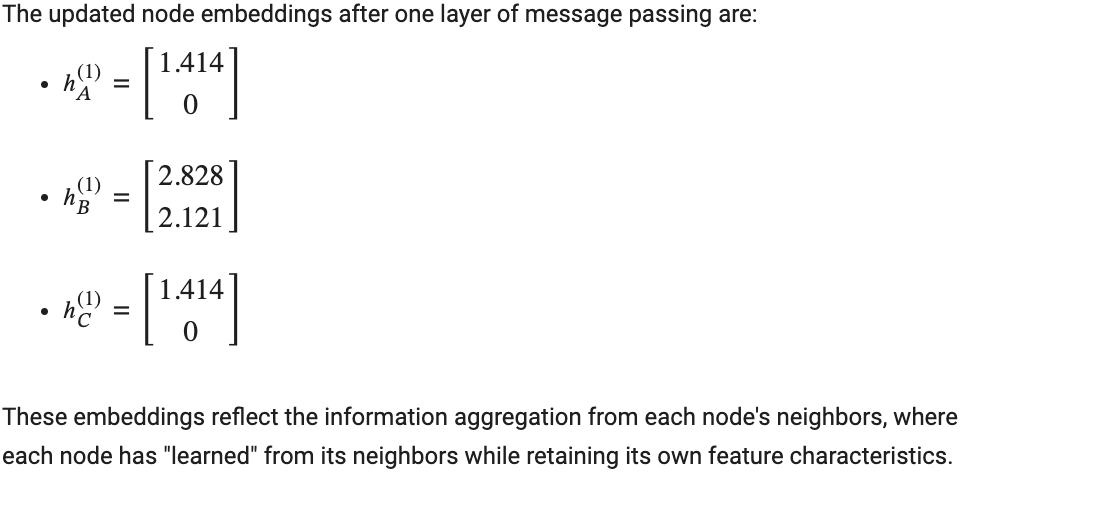
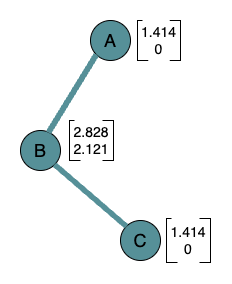

In [10]:
from IPython.display import display, HTML
import base64

DATA_DIR = "./gnn_data/"
# Paths to your images in Colab files
image_paths = [
    DATA_DIR+"/images/structure_text.png",  # First pair - Left structure text
    DATA_DIR+"/images/starting_structure.png",  # First pair - Right structure image
    DATA_DIR+"/images/initialize_text.png",  # Single image initialize text
    DATA_DIR+"/images/calculate_text.png",  # Single image calc text
    DATA_DIR+"/images/node_a_text.png",  # Second pair - Left node a text
    DATA_DIR+"/images/node_a.png",  # Second pair - Right node a image
    DATA_DIR+"/images/node_b_text.png",  # Third pair - Left node b text
    DATA_DIR+"/images/node_b.png",  # Third pair - Right node b image
    DATA_DIR+"/images/node_c_text.png",  # Fourth pair - Left node c text
    DATA_DIR+"/images/node_c.png",  # Fourth pair - Right node c image
    DATA_DIR+"/images/final_output_text.png", # Fifth pair - Left final output text
    DATA_DIR+"/images/final_structure.png"  # Fifth pair - Right final output image
]

# Titles for each section
titles = [
    "Step 1: Initialize Weights",
    "Step 2: Degree Calculation and Normalization",
    "Step 3: Aggregation and Update for Each Node",
    "Final Output After One Layer of Message Passing"
]

# Convert the images to base64 strings
base64_images = []
for path in image_paths:
    with open(path, "rb") as img_file:
        base64_images.append(base64.b64encode(img_file.read()).decode('utf-8'))

# Generate the HTML code
html_code = f"""
<div style="margin-bottom: 20px;">
    <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 10px;">
        <div style="flex: 1; text-align: center; padding-right: 10px;">
            <img src="data:image/png;base64,{base64_images[0]}" style="max-width: 100%;" />
        </div>
        <div style="flex: 1; text-align: center; padding-left: 10px;">
            <img src="data:image/png;base64,{base64_images[1]}" style="max-width: 100%;" />
        </div>
    </div>
    <hr style="border: 1px solid #ddd; margin: 20px 0;">
</div>
<div style="margin-bottom: 20px;">
    <h3 style="color: #569098; font-size: 20px;"><b>{titles[0]}</b></h3>
    <div style="text-align: center; margin-bottom: 10px;">
        <img src="data:image/png;base64,{base64_images[2]}" style="max-width: 100%;" />
    </div>
    <hr style="border: 1px solid #ddd; margin: 20px 0;">
</div>
<div style="margin-bottom: 20px;">
    <h3 style="color: #569098; font-size: 20px;"><b>{titles[1]}</b></h3>
    <div style="text-align: center; margin-bottom: 10px;">
        <img src="data:image/png;base64,{base64_images[3]}" style="max-width: 100%;" />
    </div>
    <hr style="border: 1px solid #ddd; margin: 20px 0;">
</div>
<div style="margin-bottom: 20px;">
    <h3 style="color: #569098; font-size: 20px;"><b>{titles[2]}</b></h3>
    <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 10px;">
        <div style="flex: 1; text-align: center; padding-right: 10px;">
            <img src="data:image/png;base64,{base64_images[4]}" style="max-width: 100%;" />
        </div>
        <div style="flex: 1; text-align: center; padding-left: 10px;">
            <img src="data:image/png;base64,{base64_images[5]}" style="max-width: 100%;" />
        </div>
    </div>
    <hr style="border: 1px solid #ddd; margin: 20px 0;">
</div>
<div style="margin-bottom: 20px;">
    <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 10px;">
        <div style="flex: 1; text-align: center; padding-right: 10px;">
            <img src="data:image/png;base64,{base64_images[6]}" style="max-width: 100%;" />
        </div>
        <div style="flex: 1; text-align: center; padding-left: 10px;">
            <img src="data:image/png;base64,{base64_images[7]}" style="max-width: 100%;" />
        </div>
    </div>
    <hr style="border: 1px solid #ddd; margin: 20px 0;">
</div>
<div style="margin-bottom: 20px;">
    <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 10px;">
        <div style="flex: 1; text-align: center; padding-right: 10px;">
            <img src="data:image/png;base64,{base64_images[8]}" style="max-width: 100%;" />
        </div>
        <div style="flex: 1; text-align: center; padding-left: 10px;">
            <img src="data:image/png;base64,{base64_images[9]}" style="max-width: 100%;" />
        </div>
    </div>
    <hr style="border: 1px solid #ddd; margin: 20px 0;">
</div>
<div style="margin-bottom: 20px;">
    <h3 style="color: #569098; font-size: 20px;"><b>{titles[3]}</b></h3>
    <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 10px;">
        <div style="flex: 1; text-align: center; padding-right: 10px;">
            <img src="data:image/png;base64,{base64_images[10]}" style="max-width: 100%;" />
        </div>
        <div style="flex: 1; text-align: center; padding-left: 10px;">
            <img src="data:image/png;base64,{base64_images[11]}" style="max-width: 100%;" />
        </div>
    </div>
    <hr style="border: 1px solid #ddd; margin: 20px 0;">
</div>
"""

# Display the HTML
display(HTML(html_code))
